# 1. Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# 2. Dataset Path

In [2]:
DATA_PATH = r"D:\master\02- Second Semester\04- AI\Project\EuroSAT_MS\Processed_Data\RGB_NIR"

# 3. Load Dataset

In [3]:
X = []
y = []

classes = sorted(os.listdir(DATA_PATH))

for class_name in classes:

    class_path = os.path.join(
        DATA_PATH,
        class_name
    )

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):

        if not file.endswith(".npy"):
            continue

        image = np.load(
            os.path.join(
                class_path,
                file
            )
        )

        X.append(image)
        y.append(class_name)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(27000, 64, 64, 4)
(27000,)


# 4. Encode Labels

In [4]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

num_classes = len(
    encoder.classes_
)

print(encoder.classes_)

['AnnualCrop' 'Forest' 'HerbaceousVegetation' 'Highway' 'Industrial'
 'Pasture' 'PermanentCrop' 'Residential' 'River' 'SeaLake']


# 5. Split data into (Train / Validation / Test)

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# 6. CNN Model

In [6]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,4)
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        num_classes,
        activation='softmax'
    )

])

model.summary()

c:\Users\Asmaa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,674 (2.62 MB)

 Trainable params: 685,226 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

# 7. Compile

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 8. Callbacks

In [8]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_rgb_nir_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

# 9. Train

In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_val,
        y_val
    ),
    epochs=100,
    batch_size=32,
    callbacks=[

        early_stop,

        checkpoint,

        reduce_lr
    ]
)

Epoch 1/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5338 - loss: 1.5499
Epoch 1: val_accuracy improved from -inf to 0.62025, saving model to best_rgb_nir_model.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.5340 - loss: 1.5493 - val_accuracy: 0.6202 - val_loss: 1.4953 - learning_rate: 0.0010
Epoch 2/100
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7539 - loss: 0.7422
Epoch 2: val_accuracy improved from 0.62025 to 0.69037, saving model to best_rgb_nir_model.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 47s 80ms/step - accuracy: 0.7539 - loss: 0.7421 - val_accuracy: 0.6904 - val_loss: 1.0971 - learning_rate: 0.0010
Epoch 3/100
590/591 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7890 - loss: 0.6178
Epoch 3: val_accuracy improved from 0.69037 to 0.84519, saving model to best_rgb_nir_model.keras
591/591 ━━━━━━━━━━━━━━━━━━━━ 47s 80ms/step - accuracy: 0.7891 - loss: 0.6177 - val_accuracy: 0.8452 - val_loss: 0.4381 - learning_rate: 0.0010
Epoch 4/100
591/591

In [10]:
test_loss, test_acc = model.evaluate(

    X_test,
    y_test
)

print(
    f"Test Accuracy = {test_acc:.4f}"
)

127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9665 - loss: 0.1395
Test Accuracy = 0.9627


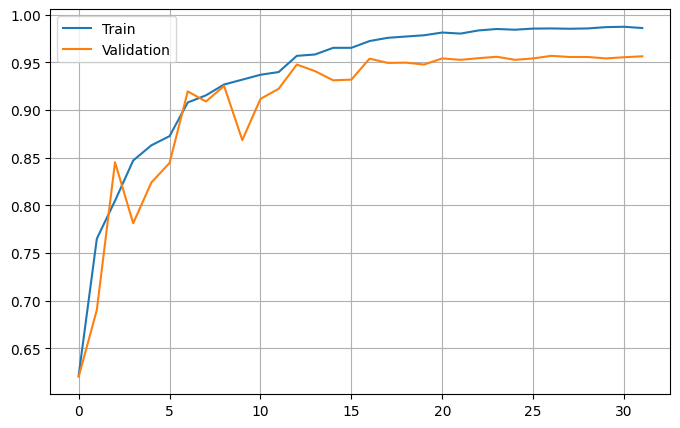

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.legend()
plt.grid()
plt.show()

127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


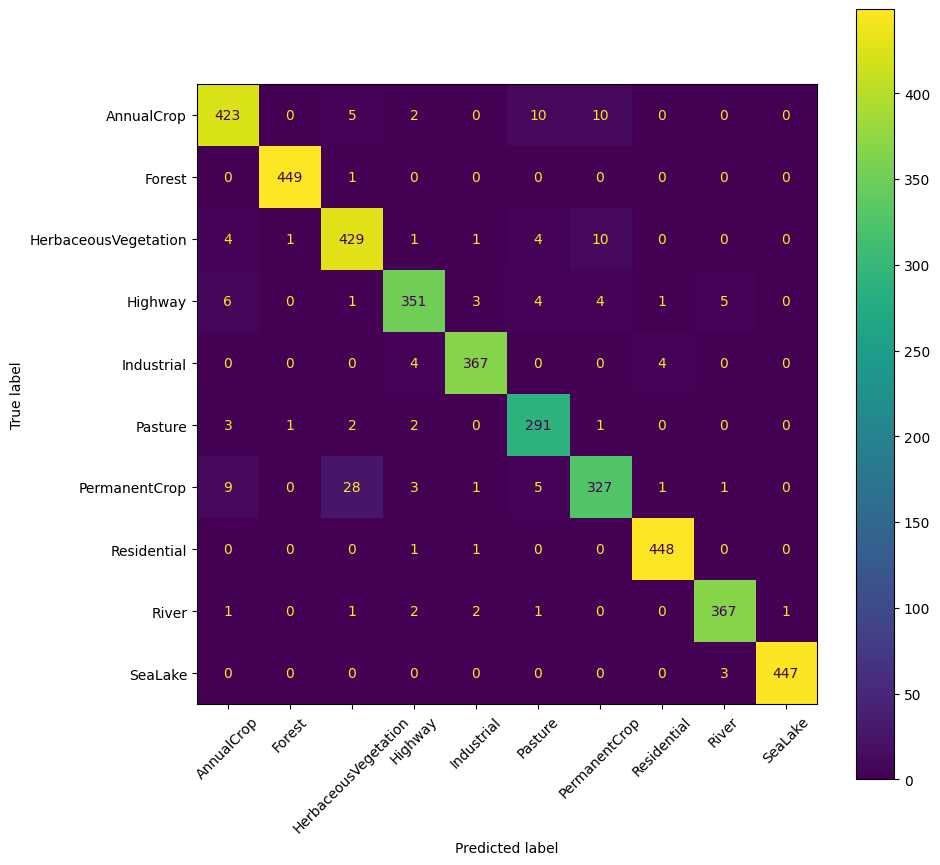

In [12]:
y_pred = model.predict(X_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

fig, ax = plt.subplots(
    figsize=(10,10)
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.show()

In [13]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.94      0.94       450
              Forest       1.00      1.00      1.00       450
HerbaceousVegetation       0.92      0.95      0.94       450
             Highway       0.96      0.94      0.95       375
          Industrial       0.98      0.98      0.98       375
             Pasture       0.92      0.97      0.95       300
       PermanentCrop       0.93      0.87      0.90       375
         Residential       0.99      1.00      0.99       450
               River       0.98      0.98      0.98       375
             SeaLake       1.00      0.99      1.00       450

            accuracy                           0.96      4050
           macro avg       0.96      0.96      0.96      4050
        weighted avg       0.96      0.96      0.96      4050

